<a href="https://colab.research.google.com/github/Huxwell/ColabNNs/blob/main/coco_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
torch.__version__

In [ ]:
!wget http://images.cocodataset.org/zips/train2017.zip

In [3]:
# 1. Download annotations (if not already downloaded)
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q annotations_trainval2017.zip

--2025-02-12 15:18:22--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.216.139, 52.217.163.225, 3.5.25.62, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.216.139|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  58.2MB/s    in 4.4s    

2025-02-12 15:18:26 (54.2 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]



In [2]:
# 1. Unzip the dataset
!unzip -q /content/train2017.zip

# 2. Install necessary libraries
!pip install pycocotools==2.0.6
!pip install matplotlib

unzip:  cannot find or open /content/train2017.zip, /content/train2017.zip.zip or /content/train2017.zip.ZIP.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycocotools: filename=pycocotools-2.0.6-cp311-cp311-linux_x86_64.whl size=400424 sha256=ba9d22e5c0213cc2c339fab5ead5518f232c07e223b008ce76be4234e73c0df5
  Stored in directory: /root/.cache/pip/wheels/ad/ca/ea/fb115e04c841c3f71fd369b7d9805a43a5193f4f9251bed0ec
Successfully built pycocotools
  Attempting uninstall: pycocotools
    Found existing installation: pycocotools 2.0.8
    Uninstalling pycocotools-2.0.8:
      Successfully uninstalled pycocotools-2.0.8


In [ ]:
# 3. Import libraries
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import os

# 4. Load COCO annotations
dataDir='/content'
dataType='train2017'
annFile='{}/annotations/instances_{}.json'.format(dataDir,dataType)
coco=COCO(annFile)



In [ ]:
# 5. Display a few images (example: 3 images)
# Get image IDs
imgIds = coco.getImgIds()[:3]  # Limit visualization to 3 images
for imgId in imgIds:
    img = coco.loadImgs(imgId)[0]
    I = plt.imread(os.path.join(dataDir, dataType, img['file_name']))
    plt.axis('off')
    plt.imshow(I)

    # Get annotations for this image
    annIds = coco.getAnnIds(imgIds=img['id'])
    anns = coco.loadAnns(annIds)

    # Display annotations (bounding boxes and labels)
    coco.showAnns(anns)

    plt.show()

# 6. Filter for images with only 1 object
# Get ALL image IDs for filtering (not just the 3 visualized)
imgIds_all = coco.getImgIds()
imgIds_single_obj = [imgId for imgId in imgIds_all
                     if len(coco.getAnnIds(imgIds=imgId)) == 1]

# 7. Dataset stats before and after filtering
print(f"Total images before filtering: {len(imgIds_all)}")
print(f"Total images after filtering (single object): {len(imgIds_single_obj)}")
# 8. Create a new COCO object with filtered data (optional)
# This creates a new COCO object with only images containing a single object.
# Use this for any further analysis on this subset.
coco_filtered = COCO()
coco_filtered.dataset = coco.dataset
coco_filtered.dataset['images'] = coco.loadImgs(imgIds_single_obj)
coco_filtered.dataset['annotations'] = coco.loadAnns(coco.getAnnIds(imgIds=imgIds_single_obj))
coco_filtered.createIndex()

In [ ]:
imgIds_filtered = coco_filtered.getImgIds()[:20]
for imgId in imgIds_filtered:
    img = coco_filtered.loadImgs(imgId)[0]
    I = plt.imread(os.path.join(dataDir, dataType, img['file_name']))
    plt.axis('off')
    plt.imshow(I)

    # Get bounding box annotations for this image
    annIds = coco_filtered.getAnnIds(imgIds=img['id'])
    anns = coco_filtered.loadAnns(annIds)

    # Display bounding boxes
    for ann in anns:
        bbox = ann['bbox']  # Get bounding box coordinates
        # Draw rectangle (adjust color and linewidth as needed)
        plt.gca().add_patch(plt.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3],
                                          linewidth=2, edgecolor='r', facecolor='none'))

    plt.show()

In [6]:
import json
import shutil
import os

# ... (previous code) ...

# 0. Download and unzip validation images (if not already downloaded)
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip -q val2017.zip

# 1. Change dataType to 'val2017'
dataType = 'val2017'
# ... (rest of the code) ...

--2025-02-12 15:22:03--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.192.157, 3.5.25.164, 3.5.25.226, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.192.157|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  34.2MB/s    in 23s     

2025-02-12 15:22:26 (33.7 MB/s) - ‘val2017.zip’ saved [815585330/815585330]



In [ ]:
import json
import shutil
import os

# ... (previous code: unzipping, installations, imports, loading COCO) ...

# 1. Change dataType to 'val2017'
dataType = 'val2017'
annFile = '{}/annotations/instances_{}.json'.format(dataDir, dataType)
coco = COCO(annFile)

# 2. Filter for images with only 1 object
imgIds_all = coco.getImgIds()
imgIds_single_obj = [imgId for imgId in imgIds_all if len(coco.getAnnIds(imgIds=imgId)) == 1]

# 3. Dataset stats before and after filtering
print(f"Total images before filtering: {len(imgIds_all)}")
print(f"Total images after filtering (single object): {len(imgIds_single_obj)}")

# 4. Create a new COCO object with filtered data
coco_filtered = COCO()
coco_filtered.dataset = coco.dataset
coco_filtered.dataset['images'] = coco.loadImgs(imgIds_single_obj)
coco_filtered.dataset['annotations'] = coco.loadAnns(coco.getAnnIds(imgIds=imgIds_single_obj))
coco_filtered.createIndex()

# 5. Create output directory
output_dir = '/content/filtered_val2017'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
output_json_path = os.path.join(output_dir, 'instances_filtered_val2017.json')

# 6. Save filtered images and JSON
for img_info in coco_filtered.dataset['images']:
  # Copy image
  source_img_path = os.path.join(dataDir, dataType, img_info['file_name'])
  dest_img_path = os.path.join(output_dir, 'images', img_info['file_name'])
  shutil.copy(source_img_path, dest_img_path)

# Save JSON
with open(output_json_path, 'w') as f:
  json.dump(coco_filtered.dataset, f, indent=4)  # Added indent=4

print(f"Filtered images and JSON saved to: {output_dir}")

In [ ]:
!ls /content

In [ ]:
import json
import shutil
import os

# ... (previous code: unzipping, installations, imports, loading COCO, filtering) ...

# 1. Re-index annotations and images
new_img_id = 1
new_ann_id = 1
id_map = {}  # Mapping from old to new IDs

for img_info in coco_filtered.dataset['images']:
    id_map[img_info['id']] = new_img_id
    img_info['id'] = new_img_id
    new_img_id += 1

for ann_info in coco_filtered.dataset['annotations']:
    ann_info['id'] = new_ann_id
    ann_info['image_id'] = id_map[ann_info['image_id']]
    new_ann_id += 1

# 2. Save re-indexed JSON
output_json_path_reindexed = os.path.join(output_dir, 'instances_filtered_1_obj_reindexed_val2017.json')
with open(output_json_path_reindexed, 'w') as f:
  json.dump(coco_filtered.dataset, f, indent=4)

print(f"Re-indexed JSON saved to: {output_json_path_reindexed}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ... (previous code: unzipping, installations, imports, loading COCO, filtering, re-indexing) ...

# 1. Zip the directory
!zip -r /content/filtered_val2017.zip /content/filtered_val2017

# 2. Download the zipped file
# from google.colab import files
# files.download('/content/filtered_val2017.zip')

 let's determine the 5 most popular classes in the COCO dataset

In [14]:
from pycocotools.coco import COCO
import collections

# Load COCO annotations (using the original annotations file)
dataDir = '/content'
dataType = 'val2017'  # Or 'train2017' if you want to check the training set
annFile = '{}/annotations/instances_{}.json'.format(dataDir, dataType)
coco = COCO(annFile)

# Get category IDs and names
cats = coco.loadCats(coco.getCatIds())
cat_names = [cat['name'] for cat in cats]

# Count the occurrences of each category in annotations
annIds = coco.getAnnIds()
anns = coco.loadAnns(annIds)
cat_counts = collections.Counter([ann['category_id'] for ann in anns])

# Get the 5 most common categories
top_cat_ids = cat_counts.most_common(20)

# Print the results
print("Most Popular Classes in COCO:")
for cat_id, count in top_cat_ids:
    cat_name = coco.loadCats(cat_id)[0]['name']
    print(f"- {cat_name} (id={cat_id}): {count} occurrences")

loading annotations into memory...
Done (t=0.87s)
creating index...
index created!
Most Popular Classes in COCO:
- person (id=1): 11004 occurrences
- car (id=3): 1932 occurrences
- chair (id=62): 1791 occurrences
- book (id=84): 1161 occurrences
- bottle (id=44): 1025 occurrences
- cup (id=47): 899 occurrences
- dining table (id=67): 697 occurrences
- traffic light (id=10): 637 occurrences
- bowl (id=51): 626 occurrences
- handbag (id=31): 540 occurrences
- bird (id=16): 440 occurrences
- boat (id=9): 430 occurrences
- truck (id=8): 415 occurrences
- umbrella (id=28): 413 occurrences
- bench (id=15): 413 occurrences
- cow (id=21): 380 occurrences
- banana (id=52): 379 occurrences
- motorcycle (id=4): 371 occurrences
- carrot (id=57): 371 occurrences
- backpack (id=27): 371 occurrences


5 Most Popular Classes in COCO:
- person: 11004 occurrences
- car: 1932 occurrences
- chair: 1791 occurrences
- book: 1161 occurrences
- bottle: 1025 occurrences



let's visualize some examples of images with the largest number of objects in the COCO dataset.

loading annotations into memory...
Done (t=1.80s)
creating index...
index created!


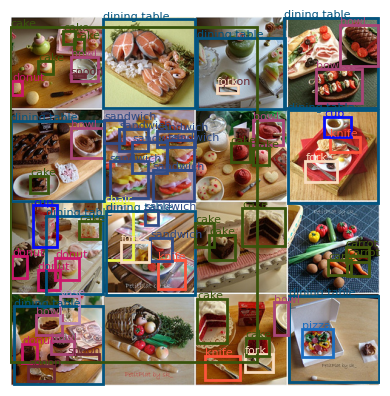

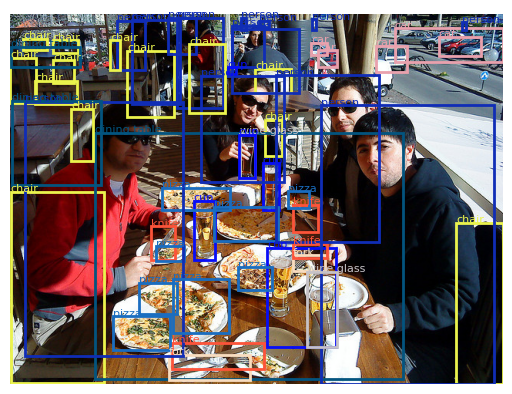

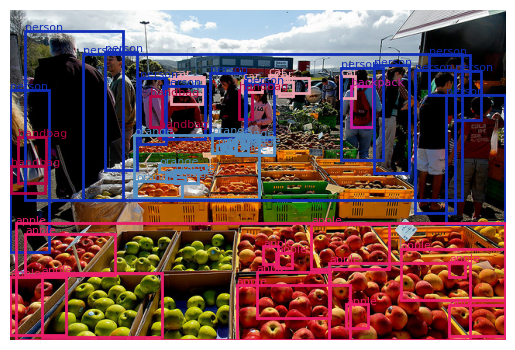

In [10]:
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import os
import random
# Load COCO annotations
dataDir = '/content'
dataType = 'val2017'  # Or 'train2017' for the training set
annFile = '{}/annotations/instances_{}.json'.format(dataDir, dataType)
coco = COCO(annFile)

# Get image IDs sorted by number of objects (descending)
imgIds = sorted(coco.getImgIds(), key=lambda imgId: len(coco.getAnnIds(imgIds=imgId)), reverse=True)

# Define a color map for categories (you can customize this)
category_colors = {}
for cat_id in coco.getCatIds():
    category_colors[cat_id] = (random.random(), random.random(), random.random())  # Assign random color

# Visualize images with bounding boxes and class labels (example: 3 images)
for imgId in imgIds[:3]:
    img = coco.loadImgs(imgId)[0]
    I = plt.imread(os.path.join(dataDir, dataType, img['file_name']))
    plt.axis('off')
    plt.imshow(I)

    # Get bounding box annotations for this image
    annIds = coco.getAnnIds(imgIds=img['id'])
    anns = coco.loadAnns(annIds)

    # Display bounding boxes with class labels and colors
    for ann in anns:
        bbox = ann['bbox']
        cat_id = ann['category_id']
        cat_name = coco.loadCats(cat_id)[0]['name']
        color = category_colors[cat_id]

        plt.gca().add_patch(plt.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3],
                                          linewidth=2, edgecolor=color, facecolor='none'))
        plt.text(bbox[0], bbox[1], cat_name, color=color, fontsize=8)  # Display class label

    plt.show()